In [4]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM


df = pd.read_csv(
    r"C:\A-CMSI research\Data\HMM data\HMM_Input_features.csv"
)

# =====================================
# Features
# =====================================

features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

X = df[features]


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


best_model = None
best_score = -np.inf

for seed in range(30):

    model = GaussianHMM(
        n_components=6,
        covariance_type="full",
        n_iter=200,
        random_state=seed
    )

    model.fit(X_scaled)

    score = model.score(X_scaled)

    if score > best_score:

        best_score = score
        best_model = model

print("="*60)
print("Best Log-Likelihood:", best_score)
print("="*60)


hidden_states = best_model.predict(X_scaled)

df["State"] = hidden_states


print("\nSTATE MEANS\n")

print(
    df.groupby("State")[[
        "SPY_Return",
        "SPY_V",
        "RollingVol21",
        "RollingSkew21",
        "Drawdown",
        "VolOfVol",
        "VIX",
        "C_t"
    ]].mean()
)


print("\nTRANSITION MATRIX\n")

print(best_model.transmat_)


logL = best_model.score(X_scaled)

n_states = best_model.n_components
n_features = X_scaled.shape[1]
n_samples = X_scaled.shape[0]


k = (
    (n_states - 1)
    + n_states * (n_states - 1)
    + n_states * n_features
    + n_states * n_features * (n_features + 1) / 2
)

AIC = -2 * logL + 2 * k

BIC = -2 * logL + np.log(n_samples) * k

print("\nMODEL SELECTION")

print("----------------------------")
print("Number of States :", n_states)
print("Log-Likelihood   :", logL)
print("Parameters       :", int(k))
print("AIC              :", AIC)
print("BIC              :", BIC)
print("----------------------------")

Best Log-Likelihood: -11740.125788565987

STATE MEANS

       SPY_Return     SPY_V  RollingVol21  RollingSkew21  Drawdown  VolOfVol  \
State                                                                          
0       -0.000684  1.062213      0.013555      -0.398700 -0.063134  0.001903   
1        0.001500 -0.924892      0.005516      -0.077493 -0.002397  0.001122   
2        0.001156 -0.587662      0.005715      -0.040155 -0.004213  0.000627   
3       -0.000178  0.109992      0.007303      -0.484964 -0.022090  0.001137   
4        0.001986  0.727435      0.024078       0.213577 -0.114972  0.007192   
5        0.000554 -0.357242      0.010971       0.065252 -0.116730  0.001019   

             VIX       C_t  
State                       
0      23.582044  0.809754  
1      15.968514  0.521727  
2      12.662544  0.541795  
3      16.759696  0.617764  
4      31.767080  0.806139  
5      19.888578  0.733298  

TRANSITION MATRIX

[[9.71735055e-001 8.01151376e-003 2.52305895e-015 6.

In [5]:
print(df["State"].value_counts().sort_index())

State
0    504
1    471
2    511
3    461
4    137
5    429
Name: count, dtype: int64


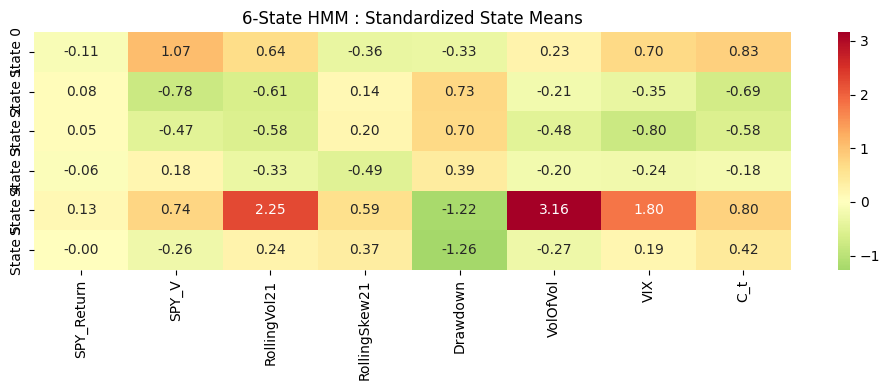

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

state_names = [
    "State 0",
    "State 1",
    "State 2",
    "State 3",
    "State 4",
    "State 5",
    
]

means = pd.DataFrame(
    best_model.means_,
    columns=features,
    index=state_names
)

plt.figure(figsize=(10,4))

sns.heatmap(
    means,
    annot=True,
    cmap="RdYlGn_r",
    center=0,
    fmt=".2f"
)

plt.title("6-State HMM : Standardized State Means")

plt.tight_layout()

plt.show()

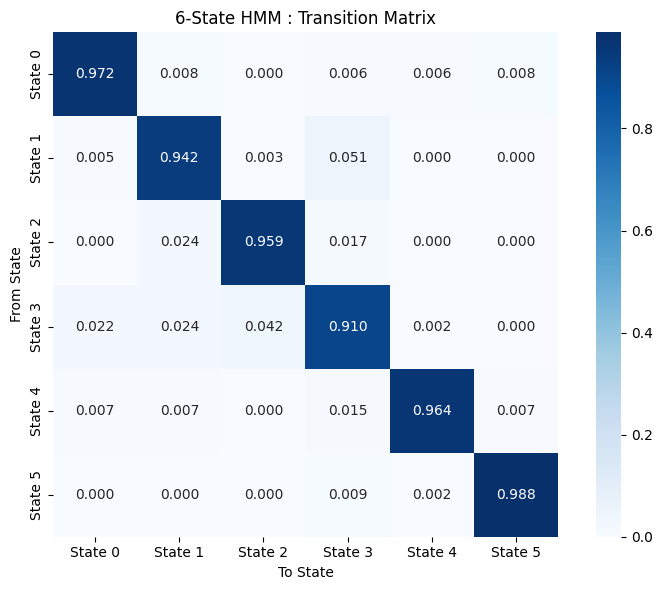

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

labels = [f"State {i}" for i in range(6)]

trans = pd.DataFrame(
    best_model.transmat_,
    index=labels,
    columns=labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    trans,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    square=True
)

plt.title("6-State HMM : Transition Matrix")
plt.xlabel("To State")
plt.ylabel("From State")

plt.tight_layout()
plt.show()

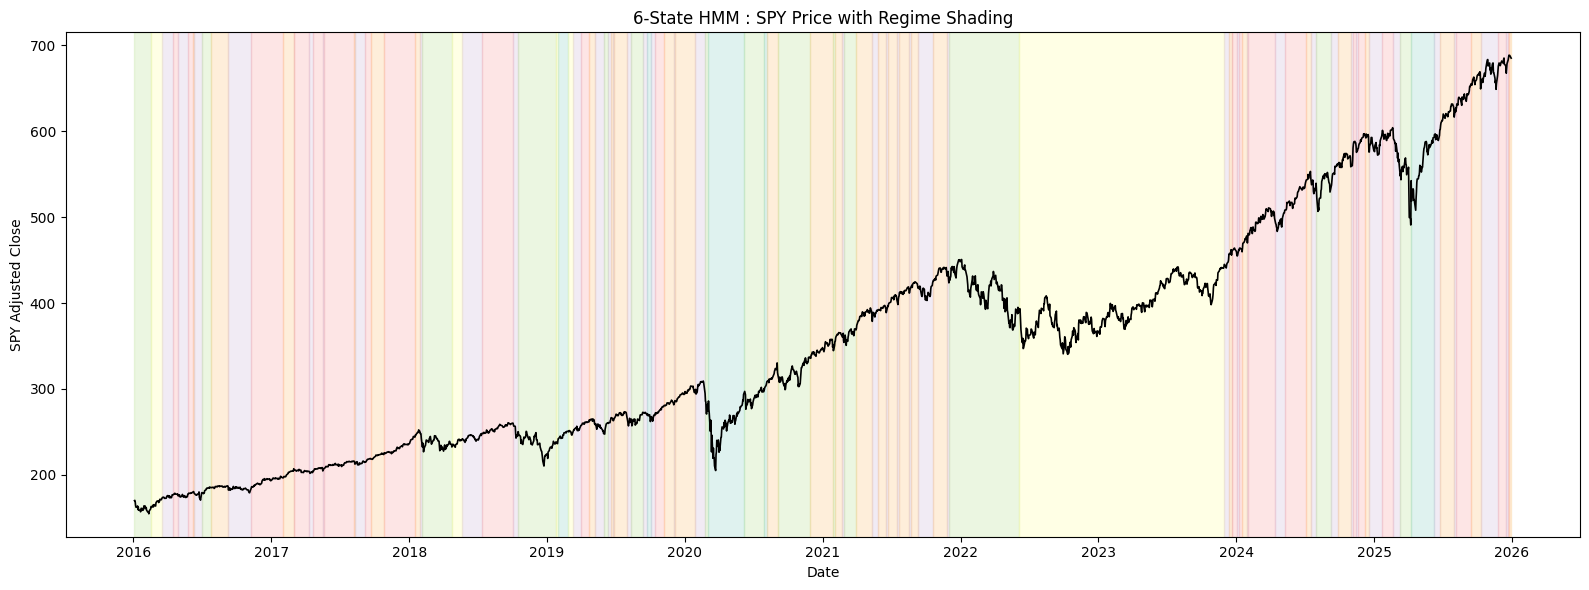

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Load SPY Prices
# ----------------------------

prices = pd.read_csv(
    r"C:/A-CMSI research/Data/prices_clean.csv"
)

prices["Date"] = pd.to_datetime(prices["Date"], dayfirst=True)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Merge HMM output with prices
plot_df = prices.merge(
    df[["Date", "State"]],
    on="Date",
    how="inner"
)

# ----------------------------
# Colors
# ----------------------------

colors = [
    "#b2df8a",   # State 0
    "#fdbf6f",   # State 1
    "#fb9a99",   # State 2
    "#cab2d6",   # State 3
    "#80cdc1",   # State 4
    "#ffff99"    # State 5
]

# ----------------------------
# Plot
# ----------------------------

fig, ax = plt.subplots(figsize=(16,6))

ax.plot(
    plot_df["Date"],
    plot_df["SPY"],
    color="black",
    linewidth=1.2,
    label="SPY"
)

# Shade each regime
current_state = plot_df["State"].iloc[0]
start = plot_df["Date"].iloc[0]

for i in range(1, len(plot_df)):

    if plot_df["State"].iloc[i] != current_state:

        ax.axvspan(
            start,
            plot_df["Date"].iloc[i],
            color=colors[current_state],
            alpha=0.25
        )

        current_state = plot_df["State"].iloc[i]
        start = plot_df["Date"].iloc[i]

# last regime
ax.axvspan(
    start,
    plot_df["Date"].iloc[-1],
    color=colors[current_state],
    alpha=0.25
)

plt.title(f"{best_model.n_components}-State HMM : SPY Price with Regime Shading")

plt.xlabel("Date")
plt.ylabel("SPY Adjusted Close")

plt.tight_layout()
plt.show()

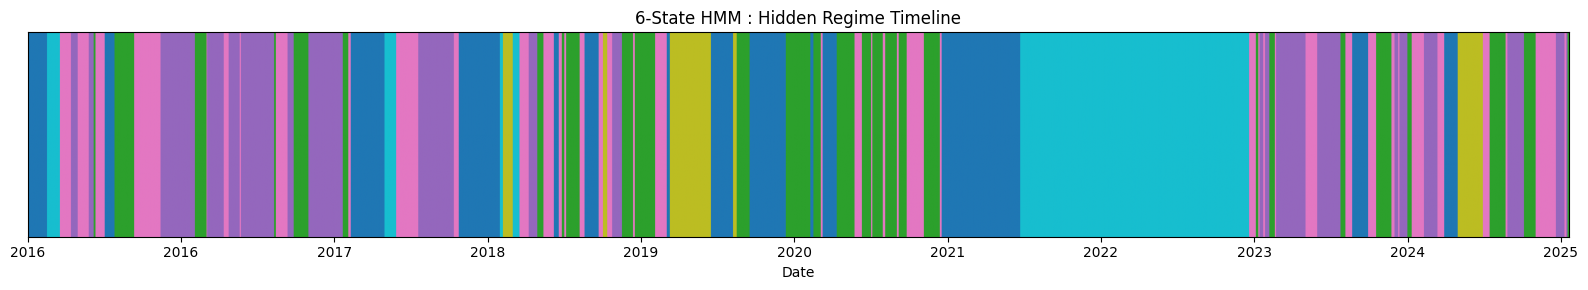

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

dates = pd.to_datetime(df["Date"])

plt.figure(figsize=(16,3))

plt.imshow(
    [df["State"]],
    aspect="auto",
    cmap="tab10",
    extent=[0, len(df), 0, 1]
)

ticks = range(0, len(df), 250)

plt.xticks(
    ticks,
    dates.iloc[ticks].dt.strftime("%Y"),
    rotation=0
)

plt.yticks([])

plt.title(f"{best_model.n_components}-State HMM : Hidden Regime Timeline")

plt.xlabel("Date")

plt.tight_layout()

plt.show()

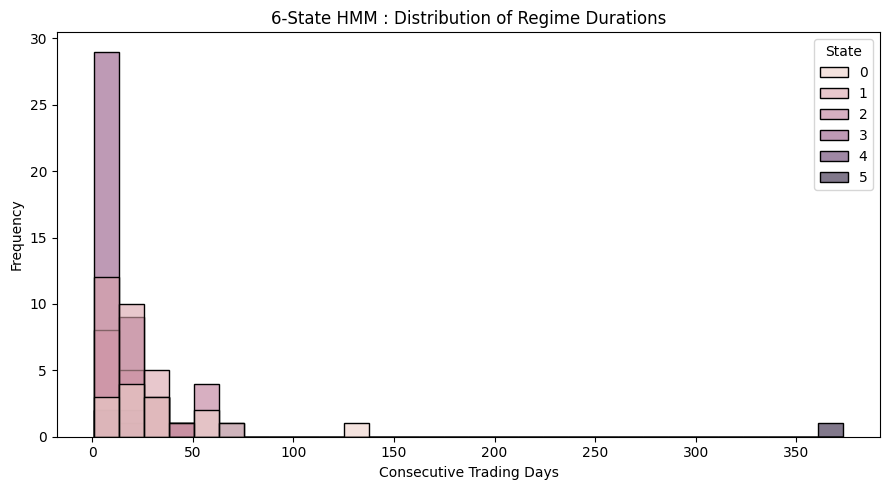

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------
# Calculate regime durations
# -------------------------------------

durations = []

current_state = df["State"].iloc[0]
length = 1

for state in df["State"].iloc[1:]:

    if state == current_state:
        length += 1

    else:
        durations.append([current_state, length])
        current_state = state
        length = 1

durations.append([current_state, length])

duration_df = pd.DataFrame(
    durations,
    columns=["State", "Duration"]
)

# -------------------------------------
# Histogram
# -------------------------------------

plt.figure(figsize=(9,5))

sns.histplot(
    data=duration_df,
    x="Duration",
    hue="State",
    bins=30,
    multiple="layer",
    alpha=0.6
)

plt.title(f"{best_model.n_components}-State HMM : Distribution of Regime Durations")

plt.xlabel("Consecutive Trading Days")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()